# 01 — Exploratory Data Analysis: Customer Churn

**Goal:** understand the data and identify churn patterns *before* modeling.

- Data comes from `churn.data.load_dataset()`: the same load → clean → validate path the training code uses. No cleaning logic is duplicated here.
- No models are trained and no features are engineered. Bands and quantiles below are for *description only*.
- Figures are saved to `reports/figures/` for reuse in the README.
- Reproducible: run top to bottom with the project venv (`Kernel → Restart & Run All`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

from churn.config import FIGURES_DIR
from churn.data import (
    CATEGORICAL_COLUMNS,
    INTERNET_ADDON_COLUMNS,
    TARGET_COLUMN,
    load_dataset,
)

%matplotlib inline
pd.set_option("display.precision", 3)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Chart style: a colour-blind-safe pair for the two classes, recessive axes and grid.
RETAINED, CHURNED = "#2a78d6", "#eb6834"
TEXT, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": TEXT,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.axisbelow": True, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "legend.frameon": False,
})


def save(fig, name):
    # Save to reports/figures/ so the README can reuse the figure.
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
df = load_dataset()
OVERALL_CHURN = df[TARGET_COLUMN].mean()

print(f"Shape: {df.shape}")
print(f"Overall churn rate: {OVERALL_CHURN:.1%}")
df.head()

Shape: (7043, 21)
Overall churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 1. Churn distribution

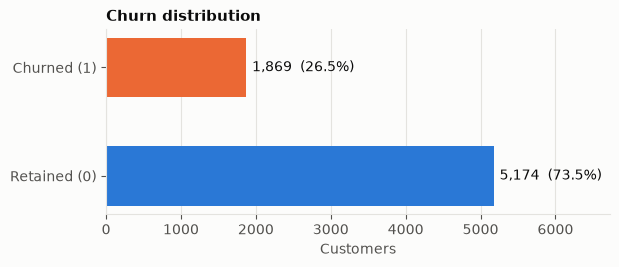

In [4]:
counts = df[TARGET_COLUMN].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 2.4))
bars = ax.barh(["Retained (0)", "Churned (1)"], counts.values, color=[RETAINED, CHURNED], height=0.55)
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{n:,}  ({n / len(df):.1%})", va="center", color=TEXT)
ax.set_xlim(0, counts.max() * 1.3)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Customers")
ax.set_title("Churn distribution")
save(fig, "01_churn_distribution")
plt.show()

About 1 in 4 customers churned. A model that always predicts "retained" would score ~73% accuracy while catching no churners, so accuracy alone is not a useful metric here.

## 2. Churn rate by categorical features

Each bar is the churn rate within that category; `n` is the number of customers. The dashed line is the overall churn rate. Small `n` means a less reliable rate.

In [5]:
def churn_rate_table(col, data=df):
    return (data.groupby(col, observed=True)[TARGET_COLUMN]
                .agg(customers="size", churn_rate="mean")
                .sort_values("churn_rate", ascending=False))


def plot_churn_rate(ax, col, title=None, order=None, xmax=0.8):
    table = churn_rate_table(col)
    if order is not None:
        table = table.loc[order]
    table = table.iloc[::-1]  # first row at the top
    bars = ax.barh([str(i) for i in table.index], table["churn_rate"], color=CHURNED, height=0.55)
    for bar, rate, n in zip(bars, table["churn_rate"], table["customers"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{rate:.0%}  (n={n:,})", va="center", fontsize=9, color=TEXT,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=0.5))
    ax.axvline(OVERALL_CHURN, color=MUTED, ls="--", lw=1)
    ax.set_xlim(0, xmax)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="y", visible=False)
    ax.set_title(title or col)


def single_churn_rate_figure(col, name, order=None, title=None):
    n_levels = df[col].nunique()
    fig, ax = plt.subplots(figsize=(7, 0.55 * n_levels + 1.0))
    plot_churn_rate(ax, col, title=title or f"Churn rate by {col}", order=order)
    ax.set_xlabel(f"Churn rate  (dashed = overall {OVERALL_CHURN:.1%})")
    save(fig, name)
    plt.show()
    return churn_rate_table(col)

### 2.1 Contract type

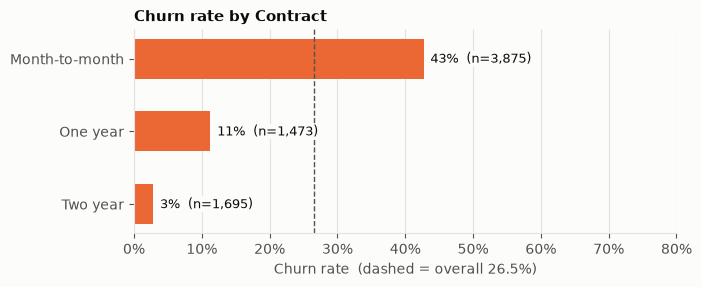

,customers,churn_rate
Contract,,
Month-to-month,3875,0.427
One year,1473,0.113
Two year,1695,0.028


In [6]:
single_churn_rate_figure("Contract", "02_churn_by_contract",
                         order=["Month-to-month", "One year", "Two year"])

### 2.2 Payment method

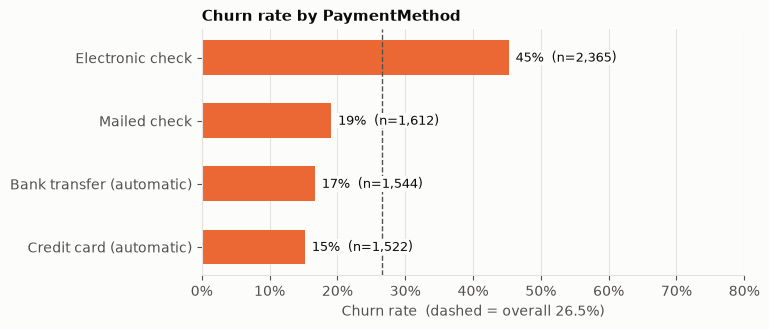

,customers,churn_rate
PaymentMethod,,
Electronic check,2365,0.453
Mailed check,1612,0.191
Bank transfer (automatic),1544,0.167
Credit card (automatic),1522,0.152


In [7]:
single_churn_rate_figure("PaymentMethod", "03_churn_by_payment_method")

### 2.3 Internet service and add-on services

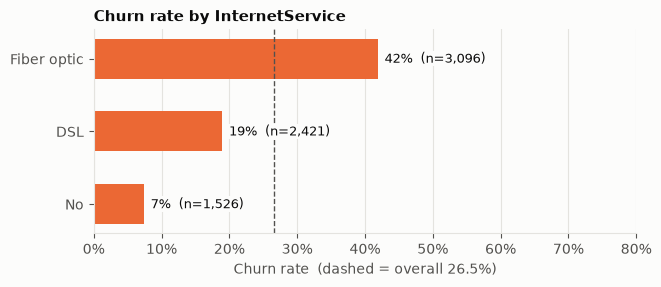

,customers,churn_rate
InternetService,,
Fiber optic,3096,0.419
DSL,2421,0.190
No,1526,0.074


In [8]:
single_churn_rate_figure("InternetService", "04_churn_by_internet_service",
                         order=["Fiber optic", "DSL", "No"])

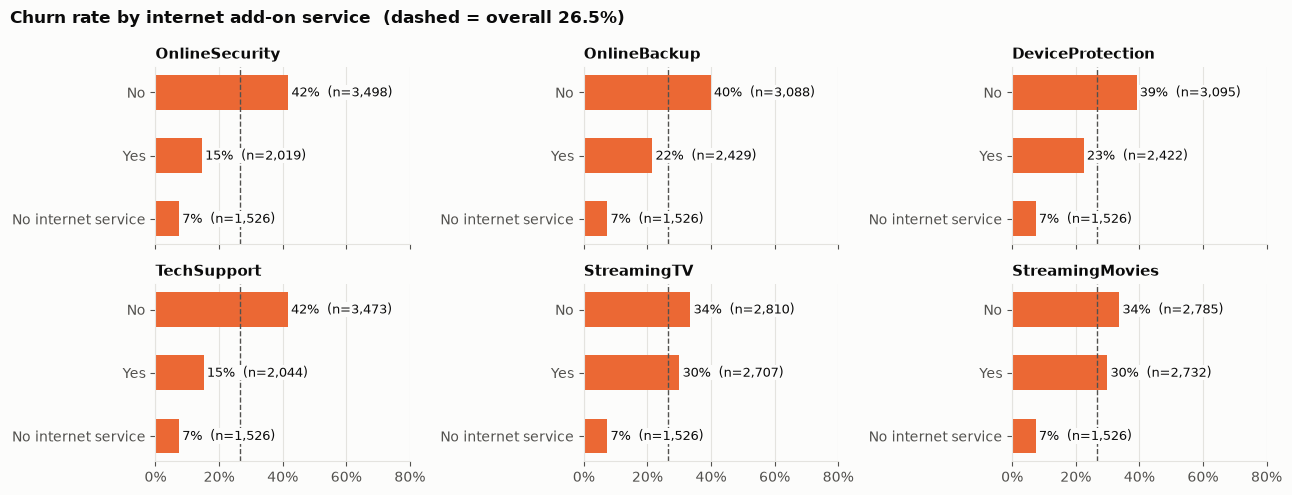

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5), sharex=True)
for ax, col in zip(axes.flat, INTERNET_ADDON_COLUMNS):
    plot_churn_rate(ax, col, order=["No", "Yes", "No internet service"])
fig.suptitle(f"Churn rate by internet add-on service  (dashed = overall {OVERALL_CHURN:.1%})",
             x=0.01, ha="left", fontweight="bold", color=TEXT)
fig.tight_layout()
save(fig, "05_churn_by_addon_services")
plt.show()

### 2.4 Demographics, phone, and billing

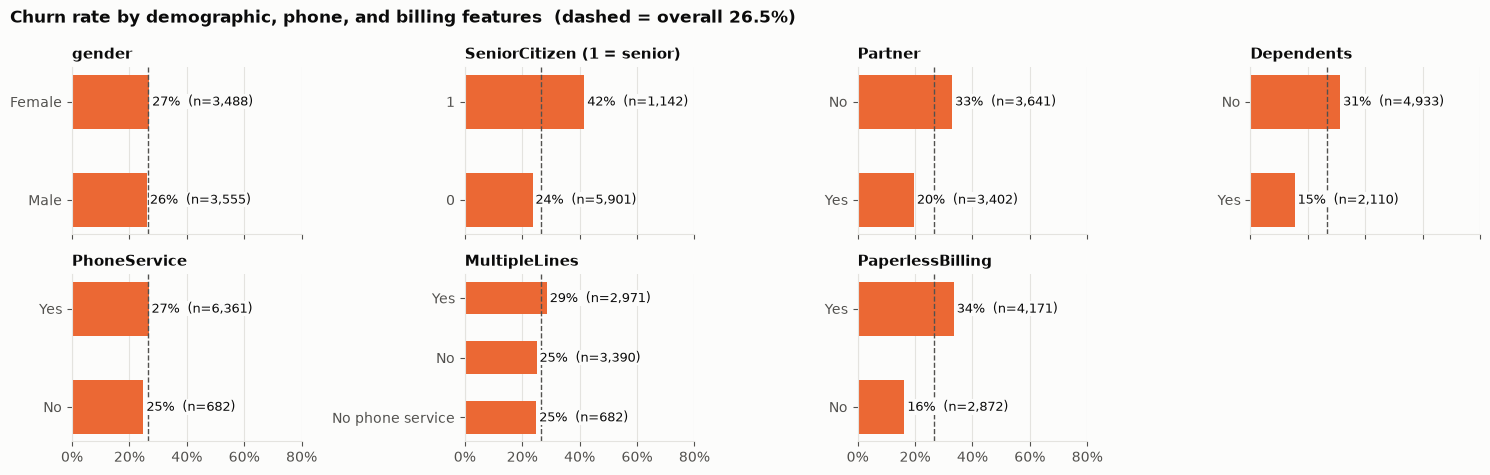

In [10]:
other_cols = ["gender", "SeniorCitizen", "Partner", "Dependents",
              "PhoneService", "MultipleLines", "PaperlessBilling"]
fig, axes = plt.subplots(2, 4, figsize=(15, 4.8), sharex=True)
for ax, col in zip(axes.flat, other_cols):
    title = "SeniorCitizen (1 = senior)" if col == "SeniorCitizen" else col
    plot_churn_rate(ax, col, title=title)
axes.flat[-1].set_visible(False)
fig.suptitle(f"Churn rate by demographic, phone, and billing features  (dashed = overall {OVERALL_CHURN:.1%})",
             x=0.01, ha="left", fontweight="bold", color=TEXT)
fig.tight_layout()
save(fig, "06_churn_by_demographics_billing")
plt.show()

### 2.5 Summary table: every categorical feature

In [11]:
rows = []
for col in CATEGORICAL_COLUMNS:
    table = churn_rate_table(col)
    rows.append({
        "feature": col,
        "levels": len(table),
        "highest_rate_level": table.index[0],
        "highest_rate": table["churn_rate"].iloc[0],
        "lowest_rate_level": table.index[-1],
        "lowest_rate": table["churn_rate"].iloc[-1],
        "spread": table["churn_rate"].iloc[0] - table["churn_rate"].iloc[-1],
        "smallest_level_n": table["customers"].min(),
    })
categorical_summary = pd.DataFrame(rows).sort_values("spread", ascending=False).reset_index(drop=True)
categorical_summary

,feature,levels,highest_rate_level,highest_rate,lowest_rate_level,lowest_rate,spread,smallest_level_n
0,Contract,3,Month-to-month,0.427,Two year,0.028,0.399,1473
1,InternetService,3,Fiber optic,0.419,No,0.074,0.345,1526
2,OnlineSecurity,3,No,0.418,No internet service,0.074,0.344,1526
3,TechSupport,3,No,0.416,No internet service,0.074,0.342,1526
4,OnlineBackup,3,No,0.399,No internet service,0.074,0.325,1526
5,DeviceProtection,3,No,0.391,No internet service,0.074,0.317,1526
6,PaymentMethod,4,Electronic check,0.453,Credit card (automatic),0.152,0.300,1522
7,StreamingMovies,3,No,0.337,No internet service,0.074,0.263,1526
8,StreamingTV,3,No,0.335,No internet service,0.074,0.261,1526
9,SeniorCitizen,2,1,0.417,0,0.236,0.181,1142


## 3. Numerical features

Left: distribution per class (density, so the smaller churned class is comparable). Right: churn rate within bands. Bands are descriptive only, not model features.

In [12]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371,24.559,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.762,30.090,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734,2266.794,0.00,398.55,1394.55,3786.60,8684.80


In [13]:
def numeric_figure(col, bands, name, xlabel, bins):
    fig, (ax_hist, ax_rate) = plt.subplots(1, 2, figsize=(13, 3.6),
                                           gridspec_kw={"width_ratios": [1.3, 1]})
    for label, value, color in [("Retained", 0, RETAINED), ("Churned", 1, CHURNED)]:
        ax_hist.hist(df.loc[df[TARGET_COLUMN] == value, col], bins=bins, density=True,
                     histtype="step", linewidth=2, color=color, label=label)
    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel("Density")
    ax_hist.set_title(f"{col} distribution by class")
    ax_hist.legend()

    banded = df.assign(band=bands)
    table = banded.groupby("band", observed=True)[TARGET_COLUMN].agg(customers="size", churn_rate="mean")
    bars = ax_rate.bar([str(b) for b in table.index], table["churn_rate"], color=CHURNED, width=0.6)
    for bar, rate, n in zip(bars, table["churn_rate"], table["customers"]):
        ax_rate.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f"{rate:.0%}\nn={n:,}", ha="center", va="bottom", fontsize=8.5, color=TEXT,
                     bbox=dict(facecolor=SURFACE, edgecolor="none", pad=0.5))
    ax_rate.axhline(OVERALL_CHURN, color=MUTED, ls="--", lw=1)
    ax_rate.set_ylim(0, 0.8)
    ax_rate.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax_rate.grid(axis="x", visible=False)
    ax_rate.set_xlabel(xlabel)
    ax_rate.set_title(f"Churn rate by {col} band  (dashed = overall)")
    fig.tight_layout()
    save(fig, name)
    plt.show()
    return table

### 3.1 Tenure (months with the company)

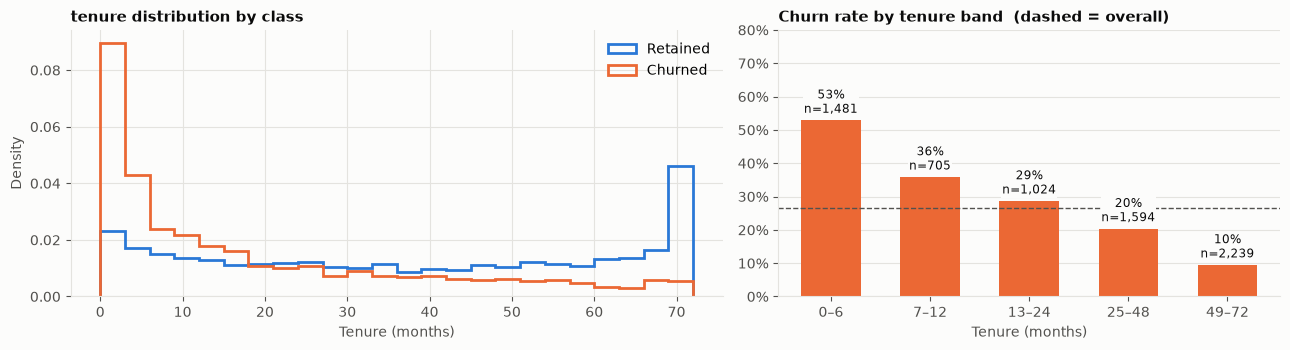

,customers,churn_rate
band,,
0–6,1481,0.529
7–12,705,0.359
13–24,1024,0.287
25–48,1594,0.204
49–72,2239,0.095


In [14]:
tenure_band = pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                     labels=["0–6", "7–12", "13–24", "25–48", "49–72"])
numeric_figure("tenure", tenure_band, "07_churn_by_tenure", "Tenure (months)", bins=range(0, 75, 3))

### 3.2 Monthly charges

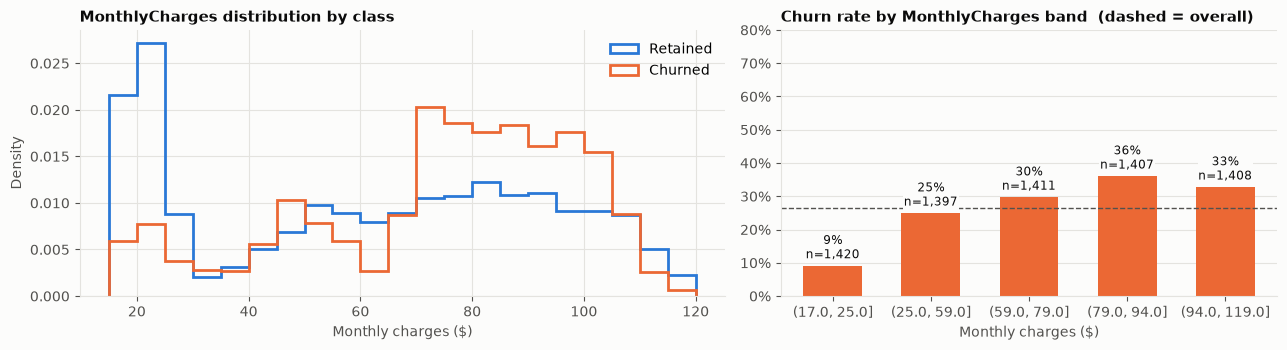

,customers,churn_rate
band,,
"(17.0, 25.0]",1420,0.092
"(25.0, 59.0]",1397,0.250
"(59.0, 79.0]",1411,0.298
"(79.0, 94.0]",1407,0.361
"(94.0, 119.0]",1408,0.328


In [15]:
charge_band = pd.qcut(df["MonthlyCharges"], q=5, precision=0)
numeric_figure("MonthlyCharges", charge_band, "08_churn_by_monthly_charges",
               "Monthly charges ($)", bins=range(15, 125, 5))

### 3.3 Is fiber's high churn just a price effect?

Fiber-optic customers pay more, so the fiber and monthly-charge patterns may overlap. Compare churn by internet type *within* the same charge band.

In [16]:
(df.assign(charge_band=charge_band)
   .pivot_table(index="charge_band", columns="InternetService", values=TARGET_COLUMN,
                aggfunc=["mean", "size"], observed=True)
   .round(3))

mean                       size                    
InternetService    DSL Fiber optic     No     DSL Fiber optic      No
charge_band                                                          
(17.0, 25.0]     0.447         NaN  0.079    47.0         NaN  1373.0
(25.0, 59.0]     0.277         NaN  0.026  1244.0         NaN   153.0
(59.0, 79.0]     0.098       0.566    NaN   808.0       603.0     NaN
(79.0, 94.0]     0.044       0.455    NaN   321.0      1086.0     NaN
(94.0, 119.0]    0.000       0.328    NaN     1.0      1407.0     NaN

## 4. `TotalCharges` and redundancy

`TotalCharges` should be roughly `tenure × MonthlyCharges`. If so, it adds little information beyond those two columns.

TotalCharges / (tenure × MonthlyCharges):
count    7032.000
mean        1.000
std         0.051
min         0.689
1%          0.855
5%          0.924
50%         1.000
95%         1.075
99%         1.159
max         1.573

Share within ±10% of 1.0: 94.6%


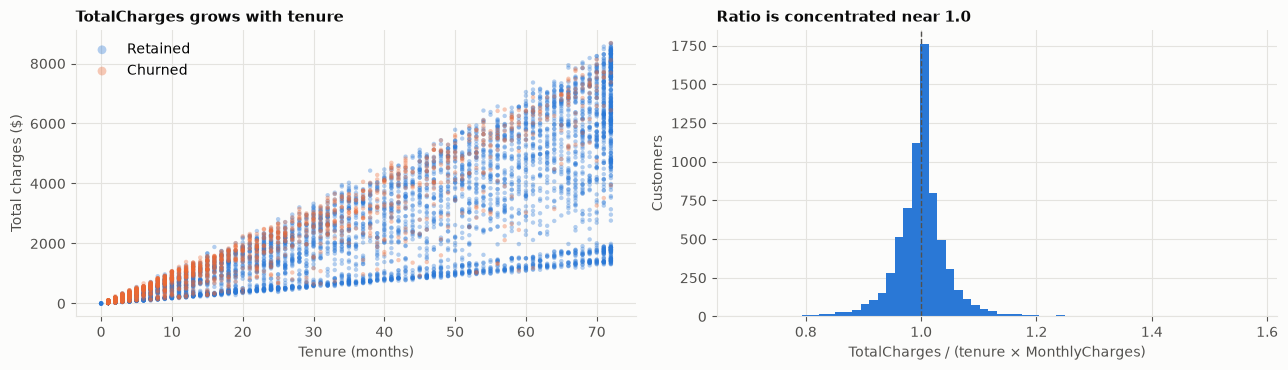

In [17]:
has_history = df["tenure"] > 0
ratio = df.loc[has_history, "TotalCharges"] / (df.loc[has_history, "tenure"] * df.loc[has_history, "MonthlyCharges"])

print("TotalCharges / (tenure × MonthlyCharges):")
print(ratio.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(3).to_string())
print(f"\nShare within ±10% of 1.0: {ratio.between(0.9, 1.1).mean():.1%}")

fig, (ax_scatter, ax_ratio) = plt.subplots(1, 2, figsize=(13, 3.8))
for label, value, color in [("Retained", 0, RETAINED), ("Churned", 1, CHURNED)]:
    subset = df[df[TARGET_COLUMN] == value]
    ax_scatter.scatter(subset["tenure"], subset["TotalCharges"], s=10, alpha=0.35,
                       color=color, label=label, edgecolors="none")
ax_scatter.set_xlabel("Tenure (months)")
ax_scatter.set_ylabel("Total charges ($)")
ax_scatter.set_title("TotalCharges grows with tenure")
ax_scatter.legend(markerscale=2)

ax_ratio.hist(ratio, bins=60, color=RETAINED)
ax_ratio.axvline(1.0, color=MUTED, ls="--", lw=1)
ax_ratio.set_xlabel("TotalCharges / (tenure × MonthlyCharges)")
ax_ratio.set_ylabel("Customers")
ax_ratio.set_title("Ratio is concentrated near 1.0")
fig.tight_layout()
save(fig, "09_total_charges_redundancy")
plt.show()

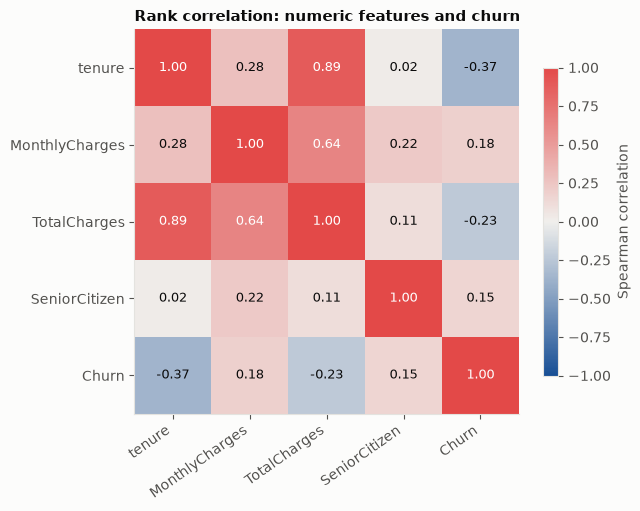

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
tenure,1.000,0.276,0.890,0.019,-0.367
MonthlyCharges,0.276,1.000,0.638,0.221,0.185
TotalCharges,0.890,0.638,1.000,0.108,-0.230
SeniorCitizen,0.019,0.221,0.108,1.000,0.151
Churn,-0.367,0.185,-0.230,0.151,1.000


In [18]:
numeric_view = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", TARGET_COLUMN]]
spearman = numeric_view.corr(method="spearman")

diverging = LinearSegmentedColormap.from_list("blue_gray_red", ["#184f95", "#f0efec", "#e34948"])
fig, ax = plt.subplots(figsize=(6.2, 5))
image = ax.imshow(spearman, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(spearman)), spearman.columns, rotation=35, ha="right")
ax.set_yticks(range(len(spearman)), spearman.index)
for i in range(len(spearman)):
    for j in range(len(spearman)):
        value = spearman.iat[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.6 else TEXT)
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="Spearman correlation")
ax.set_title("Rank correlation: numeric features and churn")
save(fig, "10_numeric_correlation")
plt.show()
spearman.round(3)

Spearman (rank) correlation is used because the relationships are monotonic but not linear, and the distributions are skewed. Correlation with the binary target is only a rough, one-variable signal.

## 5. Categorical association (Cramér's V)

Cramér's V measures association between two categorical variables (0 = none, 1 = perfect), based on the chi-squared statistic. We use it for (a) how strongly each feature relates to churn on its own, and (b) redundancy between features.

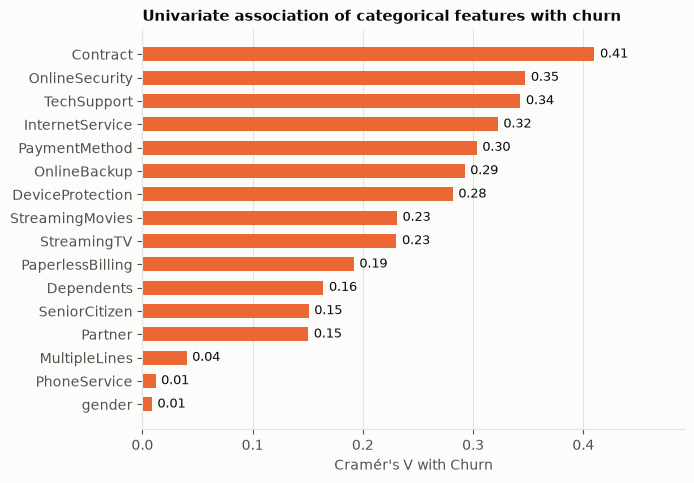

Contract            0.410
OnlineSecurity      0.347
TechSupport         0.343
InternetService     0.322
PaymentMethod       0.303
OnlineBackup        0.292
DeviceProtection    0.282
StreamingMovies     0.231
StreamingTV         0.231
PaperlessBilling    0.192
Dependents          0.164
SeniorCitizen       0.151
Partner             0.150
MultipleLines       0.040
PhoneService        0.012
gender              0.009
dtype: float64

In [19]:
def cramers_v(x, y):
    table = pd.crosstab(x, y).to_numpy()
    n = table.sum()
    expected = table.sum(axis=1, keepdims=True) @ table.sum(axis=0, keepdims=True) / n
    chi2 = ((table - expected) ** 2 / expected).sum()
    return float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))


assoc_with_churn = (pd.Series({col: cramers_v(df[col], df[TARGET_COLUMN]) for col in CATEGORICAL_COLUMNS})
                      .sort_values())

fig, ax = plt.subplots(figsize=(7, 5.2))
bars = ax.barh(assoc_with_churn.index, assoc_with_churn.values, color=CHURNED, height=0.6)
for bar, value in zip(bars, assoc_with_churn.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{value:.2f}",
            va="center", fontsize=9, color=TEXT)
ax.set_xlim(0, assoc_with_churn.max() * 1.2)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Cramér's V with Churn")
ax.set_title("Univariate association of categorical features with churn")
save(fig, "11_categorical_association_with_churn")
plt.show()
assoc_with_churn.sort_values(ascending=False).round(3)

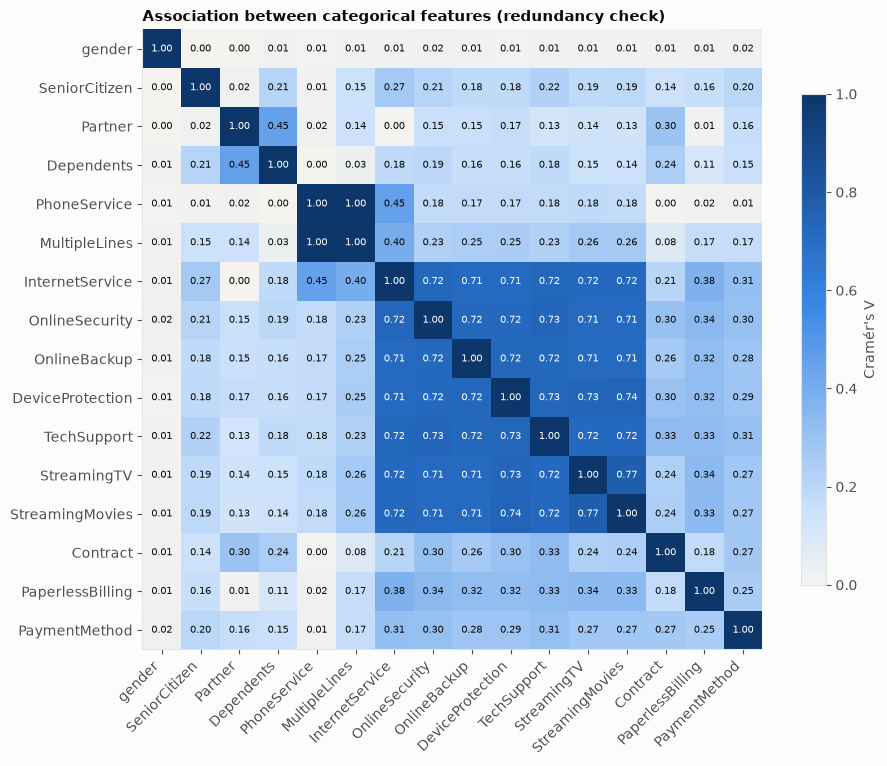

PhoneService      MultipleLines       1.000
StreamingTV       StreamingMovies     0.771
DeviceProtection  StreamingMovies     0.736
                  StreamingTV         0.734
OnlineSecurity    TechSupport         0.733
DeviceProtection  TechSupport         0.726
InternetService   OnlineSecurity      0.724
                  TechSupport         0.723
OnlineBackup      TechSupport         0.720
                  DeviceProtection    0.719
dtype: float64

In [20]:
cramers_matrix = pd.DataFrame(
    [[cramers_v(df[a], df[b]) for b in CATEGORICAL_COLUMNS] for a in CATEGORICAL_COLUMNS],
    index=CATEGORICAL_COLUMNS, columns=CATEGORICAL_COLUMNS,
)

sequential = LinearSegmentedColormap.from_list("blue_ramp", ["#f4f3f0"] + BLUE_RAMP)
fig, ax = plt.subplots(figsize=(10, 8.5))
image = ax.imshow(cramers_matrix, cmap=sequential, vmin=0, vmax=1)
ax.set_xticks(range(len(CATEGORICAL_COLUMNS)), CATEGORICAL_COLUMNS, rotation=45, ha="right")
ax.set_yticks(range(len(CATEGORICAL_COLUMNS)), CATEGORICAL_COLUMNS)
for i in range(len(CATEGORICAL_COLUMNS)):
    for j in range(len(CATEGORICAL_COLUMNS)):
        value = cramers_matrix.iat[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if value > 0.6 else TEXT)
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.75, label="Cramér's V")
ax.set_title("Association between categorical features (redundancy check)")
save(fig, "12_categorical_redundancy")
plt.show()

pairs = (cramers_matrix.where(np.triu(np.ones(cramers_matrix.shape, dtype=bool), k=1))
                       .stack().sort_values(ascending=False))
pairs.head(10).round(3)

The internet add-on columns all share the level `"No internet service"`, which is fully determined by `InternetService == "No"`. That shared level creates much of their mutual association.

## 6. Contract × tenure: are they the same signal?

Month-to-month customers also tend to be newer. If contract only mattered because of tenure, the contract gap would vanish within each tenure band.

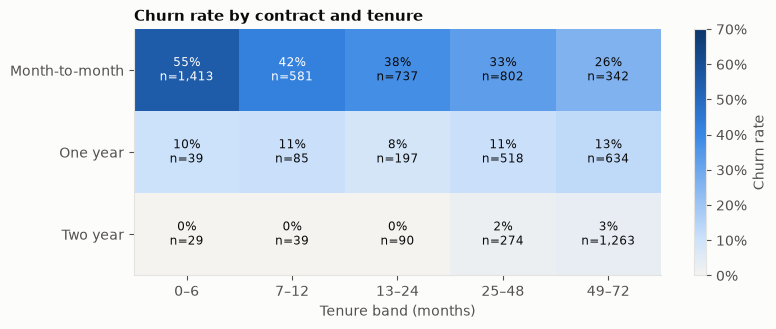

tenure_band,0–6,7–12,13–24,25–48,49–72
Contract,,,,,
Month-to-month,0.552,0.420,0.377,0.329,0.260
One year,0.103,0.106,0.081,0.106,0.129
Two year,0.000,0.000,0.000,0.022,0.033


In [21]:
grid = (df.assign(tenure_band=tenure_band)
          .pivot_table(index="Contract", columns="tenure_band", values=TARGET_COLUMN,
                       aggfunc=["mean", "size"], observed=True))
rates, sizes = grid["mean"], grid["size"]

fig, ax = plt.subplots(figsize=(8.5, 3.2))
image = ax.imshow(rates, cmap=sequential, vmin=0, vmax=0.7, aspect="auto")
ax.set_xticks(range(rates.shape[1]), [str(c) for c in rates.columns])
ax.set_yticks(range(rates.shape[0]), rates.index)
for i in range(rates.shape[0]):
    for j in range(rates.shape[1]):
        rate, n = rates.iat[i, j], sizes.iat[i, j]
        label = "—" if pd.isna(rate) else f"{rate:.0%}\nn={int(n):,}"
        ax.text(j, i, label, ha="center", va="center", fontsize=8.5,
                color="white" if (not pd.isna(rate) and rate > 0.4) else TEXT)
ax.grid(False)
ax.set_xlabel("Tenure band (months)")
fig.colorbar(image, ax=ax, label="Churn rate", format=PercentFormatter(1.0))
ax.set_title("Churn rate by contract and tenure")
save(fig, "13_churn_by_contract_and_tenure")
plt.show()
rates.round(3)

## 7. Anomalies and leakage review

In [22]:
new_customers = df[df["tenure"] == 0]
print(f"tenure == 0: {len(new_customers)} customers, churn rate {new_customers[TARGET_COLUMN].mean():.1%}")

pure_levels = []
for col in CATEGORICAL_COLUMNS:
    table = churn_rate_table(col)
    pure = table[(table["churn_rate"] == 0) | (table["churn_rate"] == 1)]
    pure_levels += [(col, level, int(row.customers)) for level, row in pure.iterrows()]
print(f"Category levels with 0% or 100% churn (would signal leakage): {pure_levels or 'none'}")

outside = ~ratio.between(0.8, 1.2)
print(f"TotalCharges ratio outside [0.8, 1.2]: {int(outside.sum())} customers "
      f"({outside.mean():.1%}), churn rate {df.loc[outside[outside].index, TARGET_COLUMN].mean():.1%}")

tenure == 0: 11 customers, churn rate 0.0%
Category levels with 0% or 100% churn (would signal leakage): none
TotalCharges ratio outside [0.8, 1.2]: 59 customers (0.8%), churn rate 23.7%


## 8. Summary of findings

All figures and numbers are from the outputs above. Associations are **descriptive, not causal**; many features are correlated with each other (e.g. contract and tenure), so single-feature churn rates overlap.

**Target**
- 26.5% churned (1,869 / 7,043). Moderate imbalance → use recall, precision, F1, ROC-AUC / PR-AUC, and stratified splits.

**Strongest signals**
- **Contract:** month-to-month 42.7% vs one-year 11.3% vs two-year 2.8%. Strongest categorical association (Cramér's V 0.41).
- **Tenure:** churn falls from 52.9% (0–6 months) to 9.5% (49–72 months); Spearman −0.37 with churn. Churners are concentrated in the first months.
- **Contract is not just tenure:** within every tenure band, month-to-month churns far more (e.g. 26% vs ≤13% at 49–72 months). Both carry signal.
- **Internet service:** fiber optic 41.9% vs DSL 19.0% vs none 7.4%. Within the same monthly-charge band, fiber still churns much more than DSL, so this is not purely a price effect.
- **Support-type add-ons:** no OnlineSecurity (41.8%) or no TechSupport (41.6%) vs ~15% with them. Streaming add-ons barely differ (34% vs 30%).
- **Payment method:** electronic check 45.3% vs 15–19% for the other three methods.
- **Monthly charges:** lowest quintile ($17–25) 9.2%; upper quintiles 30–36%. Non-linear: the top quintile is slightly below the fourth.
- **Moderate:** SeniorCitizen (41.7% vs 23.6%), PaperlessBilling, Partner, Dependents.
- **Near-zero signal:** gender (V 0.009), PhoneService (0.012), MultipleLines (0.040).

**Redundancy**
- `TotalCharges` ≈ `tenure × MonthlyCharges` (median ratio 1.000; 94.6% within ±10%); Spearman 0.89 with tenure.
- `PhoneService` is fully determined by `MultipleLines` (V = 1.00, via the "No phone service" level).
- The six internet add-ons and `InternetService` are strongly associated (V ≈ 0.71–0.77), largely through the shared "No internet service" level.

**Anomalies and leakage**
- No category level has 0% or 100% churn → no obvious target leakage in single features.
- The 11 `tenure == 0` customers all have Churn = 0 (a tiny group; not a usable pattern).
- 59 customers (0.8%) have `TotalCharges` more than 20% away from `tenure × MonthlyCharges` — likely price changes over time; their churn rate (23.7%) is close to overall.
- Caveat: this is a single snapshot; the dataset does not state when features were measured relative to churn.